In [16]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

# Autoreload extension
if 'autoreload' not in get_ipython().extension_manager.loaded:
    %load_ext autoreload
%autoreload 2

# Basic import
import eugene as eu

eu.__version__

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'0.0.6'

In [2]:
sdata = eu.datasets.ray13()

Dataset ray13 norm_data.txt.gz has already been downloaded.


In [3]:
eu.pp.train_test_split_sdata(sdata)
eu.pp.ohe_seqs_sdata(sdata, vocab="RNA")

SeqData object modified:
    seqs_annot:
        + train_val


One-hot encoding sequences:   0%|          | 0/241357 [00:00<?, ?it/s]

SeqData object modified:
	ohe_seqs: None -> 241357 ohe_seqs added


In [4]:
model_exp = eu.models.CNN(
    input_len=41,
    output_dim=1,
    strand="ss",
    aggr="max",
    task="regression",
    optimizer="adam",
    conv_kwargs={
        "conv_channels": [10, 10],
        "conv_kernels": [5, 5],
        "activations": ["exp"],
        "pool_types": []
    }
)
model_relu = eu.models.CNN(
    input_len=41,
    output_dim=1,
    strand="ss",
    aggr="max",
    task="regression",
    optimizer="adam",
    conv_kwargs={
        "conv_channels": [10, 10],
        "conv_kernels": [5, 5],
        "activations": ["relu"],
        "pool_types": []
    }
)

In [5]:
eu.train.fit(
    model_exp,
    sdata,
    target_keys=["RNCMPT00100"],
    epochs=3,
    gpus=1,
    model_checkpoint_monitor=None,
    early_stopping_metric=None,
)
eu.train.fit(
    model_relu,
    sdata,
    target_keys=["RNCMPT00100"],
    epochs=3,
    gpus=1,
    model_checkpoint_monitor=None,
    early_stopping_metric=None,
)

Global seed set to 13


Dropping 166 sequences with NaN targets.
No transforms given, assuming just need to tensorize.


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


No transforms given, assuming just need to tensorize.



  | Name         | Type        | Params
---------------------------------------------
0 | train_metric | R2Score     | 0     
1 | val_metric   | R2Score     | 0     
2 | test_metric  | R2Score     | 0     
3 | conv1d_tower | Conv1DTower | 720   
4 | dense_block  | DenseBlock  | 331   
---------------------------------------------
1.1 K     Trainable params
0         Non-trainable params
1.1 K     Total params
0.004     Total estimated model params size (MB)


...

c:\Users\Lab\anaconda3\envs\eugene\lib\site-packages\pytorch_lightning\trainer\data_loading.py:132: UserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
Global seed set to 13
c:\Users\Lab\anaconda3\envs\eugene\lib\site-packages\pytorch_lightning\trainer\data_loading.py:132: UserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [14]:
eu.interpret.generate_pfms_sdata(
    model=model_exp,
    sdata=sdata,
    vocab="RNA",
    first_layer=model_exp.conv1d_tower.layers[0],
    suffix="_exp"
)
eu.interpret.generate_pfms_sdata(
    model=model_relu,
    sdata=sdata,
    vocab="RNA",
    first_layer=model_relu.conv1d_tower.layers[0],
    suffix="_relu"
)

No transforms given, assuming just need to tensorize.


Getting maximial activating seqlets:   0%|          | 0/1885 [00:00<?, ?it/s]

Getting filter activators for 10 filters:   0%|          | 0/10 [00:00<?, ?it/s]

Getting PFMs from filters:   0%|          | 0/10 [00:00<?, ?it/s]

No transforms given, assuming just need to tensorize.


Getting maximial activating seqlets:   0%|          | 0/1885 [00:00<?, ?it/s]

Getting filter activators for 10 filters:   0%|          | 0/10 [00:00<?, ?it/s]

Getting PFMs from filters:   0%|          | 0/10 [00:00<?, ?it/s]

In [35]:
sdata.uns["pfms_exp"]

{0:           A         C         G         U
 0  1.000000  0.000000  0.000000  0.000000
 1  0.050996  0.192545  0.562846  0.193613
 2  0.681341  0.000000  0.318659  0.000000
 3  0.000000  0.994523  0.000000  0.005477
 4  0.430295  0.282745  0.286960  0.000000,
 1:           A         C         G         U
 0  1.000000  0.000000  0.000000  0.000000
 1  0.000000  0.275596  0.278970  0.445434
 2  0.054829  0.408011  0.482285  0.054875
 3  0.165504  0.000000  0.357067  0.477429
 4  0.477852  0.000000  0.522148  0.000000,
 2:           A         C         G         U
 0  0.932170  0.000000  0.067830  0.000000
 1  0.051931  0.143647  0.442372  0.362050
 2  0.578439  0.017476  0.060007  0.344078
 3  0.000000  0.000000  0.685412  0.314588
 4  0.091923  0.412958  0.280176  0.214943,
 3:           A         C         G         U
 0  0.195115  0.068153  0.645220  0.091512
 1  0.351453  0.092906  0.486251  0.069389
 2  0.356993  0.248812  0.295532  0.098663
 3  0.114633  0.403527  0.378917  0.102

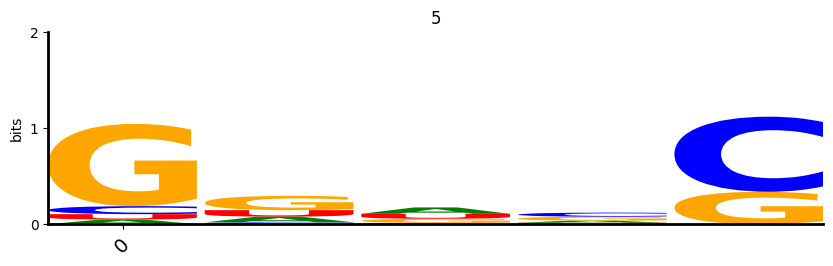

In [31]:
eu.pl.filter_viz(sdata, filter_id=5, uns_key="pfms_relu", vocab="RNA")
plt.show()